# QM9 バンドギャップ高性能予測

配布された `qm9_bandgap_train.csv` だけを教師データとして、SMILES から生成した特徴量で `gap_eV` を予測します。評価指標は MAE です。

## 成功条件とレギュレーション

- 外部データ、学習済みモデル、LLM、NNP は使わない。
- LightGBM、XGBoost、CatBoost の最大3モデルを0から学習する。
- 乱数シードは推奨値の `8` に固定する。
- OOF MAEで単体・単純平均・重み付き平均を比較する。
- 最終成果物は `smiles,gap_eV` の4,000行を持つ `submission.csv` とする。

通常モードは性能重視で長時間かかります。`QM9_FAST_MODE=1` を設定すると、構造確認用の短縮実行になります。


In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import random
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="Glyph .* missing from font.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="Argument ``multivariate`` is an experimental feature.*")

import catboost
import lightgbm as lgb
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import optuna
import pandas as pd
import rdkit
import scipy
import seaborn as sns
import sklearn
import xgboost
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from optuna.samplers import TPESampler
from optuna.trial import TrialState
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy import sparse
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import StratifiedGroupKFold, StratifiedShuffleSplit

RDLogger.DisableLog("rdApp.warning")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

FAST_MODE = os.getenv("QM9_FAST_MODE", "0") == "1"
N_SPLITS = 2 if FAST_MODE else 5
N_TRIALS = int(os.getenv("QM9_N_TRIALS", "1" if FAST_MODE else "50"))
MAX_ROUNDS = int(os.getenv("QM9_MAX_ROUNDS", "300" if FAST_MODE else "5000"))
EARLY_STOPPING_ROUNDS = int(os.getenv("QM9_EARLY_STOPPING_ROUNDS", "30" if FAST_MODE else "200"))
XGB_MAX_ROUNDS = int(os.getenv("QM9_XGB_MAX_ROUNDS", str(MAX_ROUNDS if FAST_MODE else 1200)))
XGB_EARLY_STOPPING_ROUNDS = int(
    os.getenv("QM9_XGB_EARLY_STOPPING_ROUNDS", str(EARLY_STOPPING_ROUNDS if FAST_MODE else 50))
)
CAT_N_TRIALS = int(os.getenv("QM9_CAT_N_TRIALS", str(N_TRIALS)))
CAT_MAX_ROUNDS = int(os.getenv("QM9_CAT_MAX_ROUNDS", str(MAX_ROUNDS if FAST_MODE else 8000)))
CAT_EARLY_STOPPING_ROUNDS = int(
    os.getenv("QM9_CAT_EARLY_STOPPING_ROUNDS", str(EARLY_STOPPING_ROUNDS))
)
FAST_TRAIN_ROWS = int(os.getenv("QM9_FAST_TRAIN_ROWS", "1200"))
N_THREADS = min(8, max(1, os.cpu_count() or 1))
CV_N_JOBS = N_SPLITS
MODEL_N_THREADS = max(1, (N_THREADS + CV_N_JOBS - 1) // CV_N_JOBS)
XGB_OPTUNA_N_JOBS = 2 if not FAST_MODE else 1
XGB_TUNING_THREADS = 1 if XGB_OPTUNA_N_JOBS > 1 else MODEL_N_THREADS
STUDY_VERSION = "v5"
MODEL_STUDY_VERSIONS = {"lightgbm": "v5", "xgboost": "v8", "catboost": "v7"}
MODEL_TRIAL_TARGETS = {"lightgbm": N_TRIALS, "xgboost": N_TRIALS, "catboost": CAT_N_TRIALS}

TRAIN_PATH = Path("qm9_bandgap_train.csv")
TEST_PATH = Path("qm9_bandgap_test_without_answer.csv")
SUBMISSION_PATH = Path("submission.csv")
ANSWER_PATH = Path("qm9_bandgap_test_with_answer.csv")
OPTUNA_CACHE_DIR = Path(
    os.getenv("QM9_OPTUNA_DIR", Path.home() / "Library" / "Caches" / "MI_Lab_qm9")
).expanduser()

config = {
    "fast_mode": FAST_MODE,
    "seed": SEED,
    "n_splits": N_SPLITS,
    "n_trials_per_model": MODEL_TRIAL_TARGETS,
    "max_rounds": MAX_ROUNDS,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "xgboost_max_rounds": XGB_MAX_ROUNDS,
    "xgboost_early_stopping_rounds": XGB_EARLY_STOPPING_ROUNDS,
    "catboost_max_rounds": CAT_MAX_ROUNDS,
    "catboost_early_stopping_rounds": CAT_EARLY_STOPPING_ROUNDS,
    "threads": N_THREADS,
    "parallel_cv_jobs": CV_N_JOBS,
    "threads_per_tuning_model": MODEL_N_THREADS,
    "xgboost_parallel_trials": XGB_OPTUNA_N_JOBS,
    "xgboost_threads_per_fold": XGB_TUNING_THREADS,
}
config


{'fast_mode': False,
 'seed': 8,
 'n_splits': 5,
 'n_trials_per_model': {'lightgbm': 50, 'xgboost': 50, 'catboost': 50},
 'max_rounds': 5000,
 'early_stopping_rounds': 200,
 'xgboost_max_rounds': 1200,
 'xgboost_early_stopping_rounds': 50,
 'catboost_max_rounds': 8000,
 'catboost_early_stopping_rounds': 200,
 'threads': 8,
 'parallel_cv_jobs': 5,
 'threads_per_tuning_model': 2,
 'xgboost_parallel_trials': 2,
 'xgboost_threads_per_fold': 1}

## 1. データ読み込みと入力契約

列名・行数・欠損・数値の有限性を先に確認します。提出時には元の test のSMILESと行順をそのまま保持します。


In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def validate_input_frames(train: pd.DataFrame, test: pd.DataFrame) -> None:
    if list(train.columns) != ["smiles", "gap_eV"]:
        raise ValueError(f"train列が不正です: {list(train.columns)}")
    if list(test.columns) != ["smiles"]:
        raise ValueError(f"test列が不正です: {list(test.columns)}")
    if len(train) != 15_000 or len(test) != 4_000:
        raise ValueError(f"行数が不正です: train={len(train)}, test={len(test)}")
    if train.isna().any().any() or test.isna().any().any():
        raise ValueError("入力CSVに欠損があります。")
    if (train["smiles"].str.len() == 0).any() or (test["smiles"].str.len() == 0).any():
        raise ValueError("空のSMILESがあります。")
    target = pd.to_numeric(train["gap_eV"], errors="raise").to_numpy(dtype=float)
    if not np.isfinite(target).all():
        raise ValueError("gap_eVに非有限値があります。")


train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
validate_input_frames(train_raw, test_raw)

input_summary = pd.DataFrame(
    {
        "file": [TRAIN_PATH.name, TEST_PATH.name],
        "rows": [len(train_raw), len(test_raw)],
        "sha256": [sha256_file(TRAIN_PATH)[:16], sha256_file(TEST_PATH)[:16]],
    }
)
input_summary


,file,rows,sha256
0,qm9_bandgap_train.csv,15000,24682838e7c751e6
1,qm9_bandgap_test_without_answer.csv,4000,eb998b8afa405263


## 2. EDAと最小ベースライン

目的変数の分布を確認し、各foldの学習データ中央値を予測するベースラインを後で比較対象にします。


,gap_eV
count,15000.000000
mean,6.823883
std,1.288640
min,1.774183
1%,4.035423
5%,4.726620
25%,5.885826
50%,6.781081
75%,7.834162
95%,8.868195


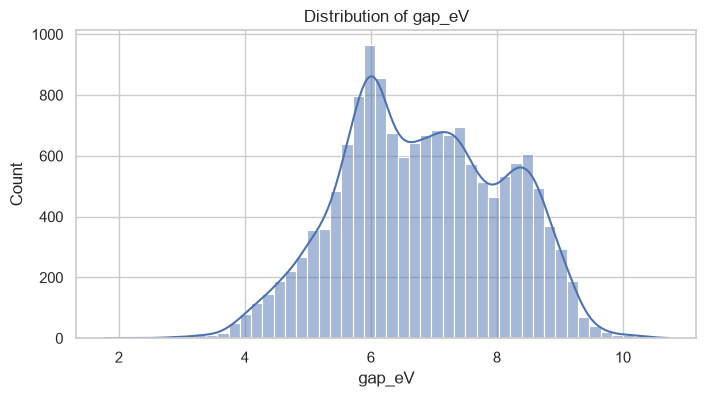

train内の完全重複行: 4行（2種類）


,smiles,gap_eV
9111,c1c(ncc(n1)N)CO,4.963359
12936,c1c(ncc(n1)N)CO,4.963359
1928,c1c(ncc(n1)O)C#N,5.230031
12515,c1c(ncc(n1)O)C#N,5.230031


In [3]:
display(train_raw["gap_eV"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train_raw["gap_eV"], bins=50, kde=True, ax=ax)
ax.set(title="Distribution of gap_eV", xlabel="gap_eV", ylabel="Count")
plt.show()

duplicate_rows = train_raw[train_raw.duplicated(["smiles", "gap_eV"], keep=False)]
print(f"train内の完全重複行: {len(duplicate_rows)}行（{duplicate_rows['smiles'].nunique()}種類）")
display(duplicate_rows.sort_values("smiles"))


## 3. SMILESの検証と化学メタデータ

RDKitで全SMILESを分子へ変換し、canonical SMILES、分子式、重原子数、Fの有無、Murcko scaffoldを求めます。同一canonical SMILESは必ず同じfoldへ入れます。


In [4]:
def parse_molecules(smiles_values: pd.Series, label: str) -> list[Chem.Mol]:
    molecules: list[Chem.Mol] = []
    invalid: list[tuple[int, str]] = []
    for index, smiles in enumerate(smiles_values.astype(str)):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            invalid.append((index, smiles))
        else:
            molecules.append(mol)
    if invalid:
        raise ValueError(f"{label}にRDKitで解釈できないSMILESがあります: {invalid[:5]}")
    return molecules


def molecule_metadata(molecules: list[Chem.Mol]) -> pd.DataFrame:
    rows = []
    for mol in molecules:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=True)
        rows.append(
            {
                "canonical_smiles": Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True),
                "formula": rdMolDescriptors.CalcMolFormula(mol),
                "scaffold": scaffold if scaffold else "__ACYCLIC__",
                "heavy_atoms": mol.GetNumHeavyAtoms(),
                "contains_f": any(atom.GetSymbol() == "F" for atom in mol.GetAtoms()),
            }
        )
    return pd.DataFrame(rows)


train_mols_all = parse_molecules(train_raw["smiles"], "train")
test_mols = parse_molecules(test_raw["smiles"], "test")
train_meta_all = molecule_metadata(train_mols_all)
test_meta = molecule_metadata(test_mols)

target_conflicts = (
    pd.DataFrame({"canonical": train_meta_all["canonical_smiles"], "target": train_raw["gap_eV"]})
    .groupby("canonical")["target"]
    .nunique()
)
if (target_conflicts > 1).any():
    raise ValueError("同じcanonical SMILESに異なるgap_eVが割り当てられています。")

canonical_overlap = set(train_meta_all["canonical_smiles"]) & set(test_meta["canonical_smiles"])
print(f"RDKit変換成功: train={len(train_mols_all)}, test={len(test_mols)}")
print(f"train/test canonical SMILES重複: {len(canonical_overlap)}")
display(
    pd.DataFrame(
        {
            "train": [train_meta_all["heavy_atoms"].min(), train_meta_all["heavy_atoms"].max(), train_meta_all["contains_f"].sum()],
            "test": [test_meta["heavy_atoms"].min(), test_meta["heavy_atoms"].max(), test_meta["contains_f"].sum()],
        },
        index=["重原子数_min", "重原子数_max", "F含有件数"],
    )
)


RDKit変換成功: train=15000, test=4000
train/test canonical SMILES重複: 0


,train,test
重原子数_min,6,8
重原子数_max,9,9
F含有件数,172,0


In [5]:
target_all = train_raw["gap_eV"].to_numpy(dtype=np.float32)
target_bins_all = pd.qcut(target_all, q=10, labels=False, duplicates="drop").astype(int)

if FAST_MODE:
    sampler = StratifiedShuffleSplit(n_splits=1, train_size=FAST_TRAIN_ROWS, random_state=SEED)
    model_indices, _ = next(sampler.split(np.zeros(len(train_raw)), target_bins_all))
    model_indices = np.sort(model_indices)
else:
    model_indices = np.arange(len(train_raw))

train_model = train_raw.iloc[model_indices].reset_index(drop=True)
train_meta = train_meta_all.iloc[model_indices].reset_index(drop=True)
train_mols = [train_mols_all[index] for index in model_indices]
y = train_model["gap_eV"].to_numpy(dtype=np.float32)
groups = train_meta["canonical_smiles"].to_numpy()
target_bins = pd.qcut(y, q=10, labels=False, duplicates="drop").astype(int)

print(f"モデリングに使用するtrain行数: {len(train_model):,}")


モデリングに使用するtrain行数: 15,000


## 4. SMILESから高情報量の特徴量を生成

次の特徴量をすべて配布SMILESから計算します。3D座標、外部データ、事前学習表現は使いません。

- RDKit 2D分子記述子
- Morgan count fingerprint（radius 2 / 3、各4096次元）
- RDKit path、AtomPair、TopologicalTorsion（各2048次元）
- MACCS keys（167次元）

大部分が0なのでLightGBMとXGBoostにはSciPy CSR疎行列を使います。CatBoostにはローカル比較で性能が確認された、2D記述子・Morgan radius 2（2048次元）・MACCSの密行列を使い、学習データで定数列を除去します。Driveへ特徴量キャッシュは保存しません。


In [6]:
DESCRIPTOR_ITEMS = list(Descriptors._descList)
MORGAN_R2 = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096, includeChirality=True)
CATBOOST_MORGAN_R2 = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
MORGAN_R3 = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=4096, includeChirality=True)
RDK_PATH = rdFingerprintGenerator.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=2048)
ATOM_PAIR = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048, includeChirality=True)
TORSION = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048, includeChirality=True)


def descriptor_matrix(molecules: list[Chem.Mol]) -> np.ndarray:
    matrix = np.empty((len(molecules), len(DESCRIPTOR_ITEMS)), dtype=np.float32)
    for row_index, mol in enumerate(molecules):
        values = []
        for _, function in DESCRIPTOR_ITEMS:
            try:
                values.append(float(function(mol)))
            except Exception:
                values.append(np.nan)
        matrix[row_index] = values
    matrix[~np.isfinite(matrix)] = np.nan
    return matrix


def count_fingerprint_matrix(
    molecules: list[Chem.Mol], generator: object, size: int
) -> sparse.csr_matrix:
    indptr = [0]
    indices: list[int] = []
    data: list[float] = []
    for mol in molecules:
        nonzero = generator.GetCountFingerprint(mol).GetNonzeroElements()
        indices.extend(nonzero.keys())
        data.extend(nonzero.values())
        indptr.append(len(indices))
    return sparse.csr_matrix(
        (np.asarray(data, dtype=np.float32), np.asarray(indices), np.asarray(indptr)),
        shape=(len(molecules), size),
        dtype=np.float32,
    )


def bit_fingerprint_matrix(
    molecules: list[Chem.Mol], generator: object, size: int
) -> sparse.csr_matrix:
    indptr = [0]
    indices: list[int] = []
    for mol in molecules:
        on_bits = list(generator.GetFingerprint(mol).GetOnBits())
        indices.extend(on_bits)
        indptr.append(len(indices))
    data = np.ones(len(indices), dtype=np.float32)
    return sparse.csr_matrix(
        (data, np.asarray(indices), np.asarray(indptr)),
        shape=(len(molecules), size),
        dtype=np.float32,
    )


def maccs_matrix(molecules: list[Chem.Mol]) -> sparse.csr_matrix:
    indptr = [0]
    indices: list[int] = []
    for mol in molecules:
        indices.extend(MACCSkeys.GenMACCSKeys(mol).GetOnBits())
        indptr.append(len(indices))
    return sparse.csr_matrix(
        (np.ones(len(indices), dtype=np.float32), np.asarray(indices), np.asarray(indptr)),
        shape=(len(molecules), 167),
        dtype=np.float32,
    )


def build_base_features(
    molecules: list[Chem.Mol], label: str, descriptor_medians: np.ndarray | None = None
) -> tuple[sparse.csr_matrix, np.ndarray]:
    started = time.time()
    print(f"{label}: RDKit特徴量を計算します（{len(molecules):,}分子）")
    descriptors = descriptor_matrix(molecules)
    if descriptor_medians is None:
        descriptor_medians = np.nanmedian(descriptors, axis=0)
        descriptor_medians = np.where(np.isfinite(descriptor_medians), descriptor_medians, 0.0)
    if np.isnan(descriptors).any():
        missing_rows, missing_columns = np.where(np.isnan(descriptors))
        descriptors[missing_rows, missing_columns] = descriptor_medians[missing_columns]
    blocks = [
        sparse.csr_matrix(descriptors, dtype=np.float32),
        count_fingerprint_matrix(molecules, MORGAN_R2, 4096),
        count_fingerprint_matrix(molecules, MORGAN_R3, 4096),
        bit_fingerprint_matrix(molecules, RDK_PATH, 2048),
        count_fingerprint_matrix(molecules, ATOM_PAIR, 2048),
        count_fingerprint_matrix(molecules, TORSION, 2048),
        maccs_matrix(molecules),
    ]
    matrix = sparse.hstack(blocks, format="csr", dtype=np.float32)
    print(f"{label}: shape={matrix.shape}, density={matrix.nnz / np.prod(matrix.shape):.4%}, {time.time() - started:.1f}秒")
    return matrix, descriptor_medians


X_base, descriptor_medians = build_base_features(train_mols, "train")
X_test_base, _ = build_base_features(test_mols, "test", descriptor_medians)

N_DESCRIPTOR_FEATURES = len(DESCRIPTOR_ITEMS)
catboost_train_morgan = count_fingerprint_matrix(train_mols, CATBOOST_MORGAN_R2, 2048).toarray()
catboost_test_morgan = count_fingerprint_matrix(test_mols, CATBOOST_MORGAN_R2, 2048).toarray()
X_catboost_raw = np.hstack(
    [X_base[:, :N_DESCRIPTOR_FEATURES].toarray(), catboost_train_morgan, X_base[:, -167:].toarray()]
)
X_catboost_test_raw = np.hstack(
    [X_test_base[:, :N_DESCRIPTOR_FEATURES].toarray(), catboost_test_morgan, X_test_base[:, -167:].toarray()]
)
CATBOOST_KEEP_MASK = X_catboost_raw.std(axis=0) > 0
X_catboost_base = np.ascontiguousarray(X_catboost_raw[:, CATBOOST_KEEP_MASK], dtype=np.float32)
X_catboost_test_base = np.ascontiguousarray(
    X_catboost_test_raw[:, CATBOOST_KEEP_MASK], dtype=np.float32
)
if not np.isfinite(X_catboost_base).all() or not np.isfinite(X_catboost_test_base).all():
    raise ValueError("CatBoost専用特徴に非有限値があります。")
del catboost_train_morgan, catboost_test_morgan, X_catboost_raw, X_catboost_test_raw
gc.collect()
print(f"CatBoost専用特徴数: {X_catboost_base.shape[1]:,}")


train: RDKit特徴量を計算します（15,000分子）
train: shape=(15000, 14720), density=2.8870%, 69.2秒
test: RDKit特徴量を計算します（4,000分子）
test: shape=(4000, 14720), density=2.9983%, 19.1秒
CatBoost専用特徴数: 2,357


## 5. fold内target encodingと交差検証

分子式とMurcko scaffoldの目的変数統計を補助特徴量にします。検証データの正解が特徴量へ混ざらないよう、各foldの学習部分だけで集計します。学習行自身にはleave-one-out値を使います。

主評価は5-fold OOF MAEです。加えて、testと同じ重原子8〜9・Fなしの領域と、fold学習側で既知／未知のscaffold別MAEを記録します。


In [7]:
FORMULA_ALPHA = 10.0
SCAFFOLD_ALPHA = 20.0


def target_encode_train_valid(
    train_categories: np.ndarray,
    train_target: np.ndarray,
    valid_categories: np.ndarray,
    alpha: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    global_mean = float(np.mean(train_target))
    frame = pd.DataFrame({"category": train_categories, "target": train_target})
    stats = frame.groupby("category", sort=False)["target"].agg(["sum", "count"])
    sums = frame["category"].map(stats["sum"]).to_numpy(dtype=float)
    counts = frame["category"].map(stats["count"]).to_numpy(dtype=float)
    if len(train_target) < 2:
        raise ValueError("target encodingには2行以上の学習データが必要です。")
    global_loo = (float(np.sum(train_target)) - train_target) / (len(train_target) - 1)
    train_encoded = (sums - train_target + alpha * global_loo) / (counts - 1.0 + alpha)
    smoothed = (stats["sum"] + alpha * global_mean) / (stats["count"] + alpha)
    valid_series = pd.Series(valid_categories)
    valid_encoded = valid_series.map(smoothed).fillna(global_mean).to_numpy(dtype=float)
    valid_counts = valid_series.map(stats["count"]).fillna(0.0).to_numpy(dtype=float)
    return (
        train_encoded.astype(np.float32),
        valid_encoded.astype(np.float32),
        np.log1p(np.maximum(counts - 1.0, 0.0)).astype(np.float32),
        np.log1p(valid_counts).astype(np.float32),
    )


def append_fold_target_encoding(
    train_indices: np.ndarray, valid_indices: np.ndarray
) -> tuple[sparse.csr_matrix, sparse.csr_matrix]:
    feature_columns_train = []
    feature_columns_valid = []
    for column, alpha in [("formula", FORMULA_ALPHA), ("scaffold", SCAFFOLD_ALPHA)]:
        train_encoded, valid_encoded, train_counts, valid_counts = target_encode_train_valid(
            train_meta.iloc[train_indices][column].to_numpy(),
            y[train_indices],
            train_meta.iloc[valid_indices][column].to_numpy(),
            alpha,
        )
        feature_columns_train.extend([train_encoded, train_counts])
        feature_columns_valid.extend([valid_encoded, valid_counts])
    train_extra = sparse.csr_matrix(np.column_stack(feature_columns_train), dtype=np.float32)
    valid_extra = sparse.csr_matrix(np.column_stack(feature_columns_valid), dtype=np.float32)
    return (
        sparse.hstack([X_base[train_indices], train_extra], format="csr"),
        sparse.hstack([X_base[valid_indices], valid_extra], format="csr"),
    )


splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_indices = list(splitter.split(X_base, target_bins, groups=groups))
fold_data = []
fold_id = np.empty(len(y), dtype=int)
known_scaffold_oof = np.zeros(len(y), dtype=bool)
baseline_oof = np.empty(len(y), dtype=np.float32)

for fold_number, (train_indices, valid_indices) in enumerate(fold_indices):
    X_train_fold, X_valid_fold = append_fold_target_encoding(train_indices, valid_indices)
    fold_data.append((train_indices, valid_indices, X_train_fold, X_valid_fold))
    fold_id[valid_indices] = fold_number
    baseline_oof[valid_indices] = np.median(y[train_indices])
    known = set(train_meta.iloc[train_indices]["scaffold"])
    known_scaffold_oof[valid_indices] = train_meta.iloc[valid_indices]["scaffold"].isin(known)

fold_data_by_model = {"lightgbm": fold_data, "xgboost": fold_data}
fold_data_by_model["catboost"] = [
    (
        train_indices,
        valid_indices,
        X_catboost_base[train_indices],
        X_catboost_base[valid_indices],
    )
    for train_indices, valid_indices, X_train_fold, X_valid_fold in fold_data
]

test_like_mask = train_meta["heavy_atoms"].between(8, 9).to_numpy() & ~train_meta["contains_f"].to_numpy()
print(f"fold数: {len(fold_data)}, 追加特徴量込み次元: {fold_data[0][2].shape[1]}")
print(f"CatBoost専用次元: {fold_data_by_model['catboost'][0][2].shape[1]}（密行列）")
print(f"中央値ベースライン OOF MAE: {mean_absolute_error(y, baseline_oof):.6f}")


fold数: 5, 追加特徴量込み次元: 14724
CatBoost専用次元: 2357（密行列）
中央値ベースライン OOF MAE: 1.075058


## 6. 3モデルのOptuna探索

検証指標はMAEで統一します。LightGBMはL1、XGBoostとCatBoostはRMSE目的で学習し、いずれもMAEでearly stoppingします。CatBoostはローカル比較で強かった設定を最初のtrialに入れ、MVS bootstrapとコンパクト特徴で探索します。trial内のfoldを共有メモリのスレッドで並列学習し、XGBoostはCPUを使い切るため2 trialを並列実行します。studyは入力ハッシュと実効設定を含むSQLiteとして、Drive外かつ再起動後も残る `~/Library/Caches/MI_Lab_qm9/` に保存するため、中断時に再利用できます。


In [8]:
MODEL_NAMES = ["lightgbm", "xgboost", "catboost"]


def suggest_parameters(trial: optuna.Trial, model_name: str) -> dict:
    if model_name == "lightgbm":
        max_depth = trial.suggest_int("max_depth", 4, 12)
        return {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "max_depth": max_depth,
            "num_leaves": trial.suggest_int("num_leaves", 16, min(384, 2**max_depth)),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.35, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 30.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 100.0, log=True),
            "min_split_gain": trial.suggest_float("min_split_gain", 1e-8, 1.0, log=True),
            "max_bin": trial.suggest_categorical("max_bin", [127, 255, 511]),
        }
    if model_name == "xgboost":
        return {
            "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.20, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 7),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 30.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.35, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-8, 3.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 30.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
            "max_bin": trial.suggest_categorical("max_bin", [128, 256]),
        }
    if model_name == "catboost":
        return {
            "learning_rate": trial.suggest_float("learning_rate", 0.035, 0.08, log=True),
            "depth": trial.suggest_int("depth", 6, 8),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 20.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 1e-3, 2.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.70, 1.0),
            "rsm": trial.suggest_float("rsm", 0.55, 0.90),
        }
    raise KeyError(model_name)


def fit_model(
    model_name: str,
    params: dict,
    X_train: sparse.csr_matrix | np.ndarray,
    y_train: np.ndarray,
    X_valid: sparse.csr_matrix | np.ndarray | None = None,
    y_valid: np.ndarray | None = None,
    rounds: int | None = None,
    model_threads: int | None = None,
) -> tuple[object, int]:
    use_validation = X_valid is not None and y_valid is not None
    if model_name == "xgboost":
        default_rounds = XGB_MAX_ROUNDS
    elif model_name == "catboost":
        default_rounds = CAT_MAX_ROUNDS
    else:
        default_rounds = MAX_ROUNDS
    n_estimators = int(rounds or default_rounds)
    threads = int(model_threads or N_THREADS)

    if model_name == "lightgbm":
        model = LGBMRegressor(
            objective="regression_l1",
            n_estimators=n_estimators,
            random_state=SEED,
            n_jobs=threads,
            verbosity=-1,
            deterministic=True,
            force_col_wise=True,
            subsample_freq=1,
            **params,
        )
        fit_kwargs = {}
        if use_validation:
            fit_kwargs = {
                "eval_set": [(X_valid, y_valid)],
                "eval_metric": "mae",
                "callbacks": [
                    lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                    lgb.log_evaluation(0),
                ],
            }
        model.fit(X_train, y_train, **fit_kwargs)
        best_round = int(getattr(model, "best_iteration_", 0) or n_estimators)
        return model, best_round

    if model_name == "xgboost":
        model_kwargs = {
            "objective": "reg:squarederror",
            "eval_metric": "mae",
            "tree_method": "hist",
            "n_estimators": n_estimators,
            "random_state": SEED,
            "n_jobs": threads,
            "verbosity": 0,
            **params,
        }
        if use_validation:
            model_kwargs["early_stopping_rounds"] = XGB_EARLY_STOPPING_ROUNDS
        model = xgboost.XGBRegressor(**model_kwargs)
        fit_kwargs = {"eval_set": [(X_valid, y_valid)], "verbose": False} if use_validation else {}
        model.fit(X_train, y_train, **fit_kwargs)
        best_iteration = getattr(model, "best_iteration", None)
        best_round = int(best_iteration + 1) if best_iteration is not None else n_estimators
        return model, best_round

    if model_name == "catboost":
        model_kwargs = {
            "loss_function": "RMSE",
            "eval_metric": "MAE",
            "iterations": n_estimators,
            "random_seed": SEED,
            "thread_count": threads,
            "verbose": False,
            "allow_writing_files": False,
            "bootstrap_type": "MVS",
            "use_best_model": use_validation,
            **params,
        }
        if use_validation:
            model_kwargs.update({"od_type": "Iter", "od_wait": CAT_EARLY_STOPPING_ROUNDS})
        model = CatBoostRegressor(**model_kwargs)
        fit_kwargs = {"eval_set": (X_valid, y_valid)} if use_validation else {}
        model.fit(X_train, y_train, **fit_kwargs)
        best_iteration = model.get_best_iteration() if use_validation else -1
        best_round = int(best_iteration + 1) if best_iteration >= 0 else n_estimators
        return model, best_round

    raise KeyError(model_name)


def evaluate_tuning_fold(model_name: str, params: dict, fold_number: int) -> tuple[int, float, int]:
    train_indices, valid_indices, X_train_fold, X_valid_fold = fold_data_by_model[model_name][fold_number]
    model, best_round = fit_model(
        model_name,
        params,
        X_train_fold,
        y[train_indices],
        X_valid_fold,
        y[valid_indices],
        model_threads=XGB_TUNING_THREADS if model_name == "xgboost" else MODEL_N_THREADS,
    )
    prediction = model.predict(X_valid_fold)
    score = float(mean_absolute_error(y[valid_indices], prediction))
    del model, prediction
    return fold_number, score, best_round


def make_objective(model_name: str):
    def objective(trial: optuna.Trial) -> float:
        params = suggest_parameters(trial, model_name)
        with ThreadPoolExecutor(max_workers=CV_N_JOBS) as executor:
            results = list(
                executor.map(
                    lambda fold_number: evaluate_tuning_fold(model_name, params, fold_number),
                    range(N_SPLITS),
                )
            )
        scores = []
        for fold_number, score, best_round in sorted(results):
            scores.append(score)
            trial.report(float(np.mean(scores)), step=fold_number)
            trial.set_user_attr(f"best_round_fold_{fold_number}", best_round)
        gc.collect()
        return float(np.mean(scores))

    return objective


In [9]:
study_hash_payload = {
    "train_sha256": sha256_file(TRAIN_PATH),
    "test_sha256": sha256_file(TEST_PATH),
    "study_version": STUDY_VERSION,
    "fast_mode": FAST_MODE,
    "n_splits": N_SPLITS,
    "max_rounds": MAX_ROUNDS,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "fast_train_rows": FAST_TRAIN_ROWS if FAST_MODE else None,
    "parallel_cv_jobs": CV_N_JOBS,
    "threads_per_tuning_model": MODEL_N_THREADS,
}
input_hash = hashlib.sha256(
    json.dumps(study_hash_payload, sort_keys=True).encode()
).hexdigest()[:16]
OPTUNA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
study_db = OPTUNA_CACHE_DIR / f"qm9_bandgap_optuna_{input_hash}.sqlite3"
storage = f"sqlite:///{study_db}"
studies: dict[str, optuna.Study] = {}
best_params: dict[str, dict] = {}
existing_study_names = {summary.study_name for summary in optuna.get_all_study_summaries(storage)}


def parameter_signature(trial: optuna.trial.FrozenTrial) -> str:
    return json.dumps(trial.params, sort_keys=True, ensure_ascii=True, default=str)


def unique_completed_count(study: optuna.Study) -> int:
    return len(
        {parameter_signature(trial) for trial in study.trials if trial.state == TrialState.COMPLETE}
    )

for model_name in MODEL_NAMES:
    model_study_version = MODEL_STUDY_VERSIONS[model_name]
    study_name = f"{model_study_version}_{model_name}_{'fast' if FAST_MODE else 'full'}_{N_SPLITS}fold"
    if study_name in existing_study_names:
        prior_study = optuna.load_study(study_name=study_name, storage=storage)
        sampler_seed = SEED + len(prior_study.trials)
    else:
        sampler_seed = SEED
    study = optuna.create_study(
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
        direction="minimize",
        sampler=TPESampler(seed=sampler_seed),
    )
    if model_name == "catboost" and len(study.trials) == 0:
        study.enqueue_trial(
            {
                "learning_rate": 0.05,
                "depth": 8,
                "l2_leaf_reg": 3.0,
                "random_strength": 1.0,
                "subsample": 0.8,
                "rsm": 0.8,
            }
        )
    while True:
        unique_completed = unique_completed_count(study)
        remaining = max(0, MODEL_TRIAL_TARGETS[model_name] - unique_completed)
        print(
            f"{model_name}: 一意な完了済み={unique_completed}, 今回実行={remaining}, "
            f"resume_seed={sampler_seed}"
        )
        if remaining == 0:
            break
        unique_before = unique_completed
        study.optimize(
            make_objective(model_name),
            n_trials=remaining,
            n_jobs=XGB_OPTUNA_N_JOBS if model_name == "xgboost" else 1,
            gc_after_trial=True,
            show_progress_bar=False,
            callbacks=[
                lambda current_study, trial: print(
                    f"  trial {trial.number + 1}: MAE={trial.value:.6f}, best={current_study.best_value:.6f}"
                )
                if trial.state == TrialState.COMPLETE and ((trial.number + 1) % 5 == 0 or FAST_MODE)
                else None
            ],
        )
        if unique_completed_count(study) <= unique_before:
            raise RuntimeError(f"{model_name}: 一意な完了trialが増えませんでした。")
    studies[model_name] = study
    best_params[model_name] = dict(study.best_params)
    print(f"{model_name}: best CV MAE={study.best_value:.6f}")

tuning_summary = pd.DataFrame(
    [
        {"model": name, "best_cv_mae": studies[name].best_value, "params": json.dumps(best_params[name], ensure_ascii=False)}
        for name in MODEL_NAMES
    ]
).sort_values("best_cv_mae")
display(tuning_summary)


lightgbm: 一意な完了済み=50, 今回実行=0, resume_seed=58
lightgbm: best CV MAE=0.209264
xgboost: 一意な完了済み=50, 今回実行=0, resume_seed=59
xgboost: best CV MAE=0.204745
catboost: 一意な完了済み=50, 今回実行=0, resume_seed=58
catboost: best CV MAE=0.194889


,model,best_cv_mae,params
2,catboost,0.194889,"{""learning_rate"": 0.04166612287988084, ""depth""..."
1,xgboost,0.204745,"{""learning_rate"": 0.07013905338916718, ""max_de..."
0,lightgbm,0.209264,"{""max_depth"": 5, ""learning_rate"": 0.0690321114..."


## 7. OOF予測とアンサンブル選択

探索済みパラメータでOOF予測を作り直します。単体3種、単純平均、非負かつ総和1の重み付き平均を同じOOF MAEで比較し、最小のものだけを最終提出へ採用します。

この値は設定選択にも使うため、完全に独立した未知データ評価ではありません。モデル間比較と提出設定選択のための指標です。


In [10]:
oof_predictions: dict[str, np.ndarray] = {}
best_rounds: dict[str, list[int]] = {}

for model_name in MODEL_NAMES:
    oof = np.empty(len(y), dtype=np.float64)
    rounds_for_model = []
    print(f"{model_name}: OOF予測を作成")
    for train_indices, valid_indices, X_train_fold, X_valid_fold in fold_data_by_model[model_name]:
        model, best_round = fit_model(
            model_name,
            best_params[model_name],
            X_train_fold,
            y[train_indices],
            X_valid_fold,
            y[valid_indices],
        )
        oof[valid_indices] = model.predict(X_valid_fold)
        rounds_for_model.append(best_round)
        del model
        gc.collect()
    oof_predictions[model_name] = oof
    best_rounds[model_name] = rounds_for_model
    print(f"  OOF MAE={mean_absolute_error(y, oof):.6f}, best rounds={rounds_for_model}")

prediction_matrix = np.column_stack([oof_predictions[name] for name in MODEL_NAMES])
equal_weights = np.full(len(MODEL_NAMES), 1.0 / len(MODEL_NAMES))


def blend_loss(weights: np.ndarray) -> float:
    return float(mean_absolute_error(y, prediction_matrix @ weights))


starts = [equal_weights] + [np.eye(len(MODEL_NAMES))[index] for index in range(len(MODEL_NAMES))]
optimizations = [
    minimize(
        blend_loss,
        start,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * len(MODEL_NAMES),
        constraints={"type": "eq", "fun": lambda weights: np.sum(weights) - 1.0},
        options={"maxiter": 1000, "ftol": 1e-12},
    )
    for start in starts
]
successful = [result for result in optimizations if result.success]
if not successful:
    raise RuntimeError("アンサンブル重みの最適化に失敗しました。")
weighted_result = min(successful, key=lambda result: result.fun)
weighted_weights = np.clip(weighted_result.x, 0.0, 1.0)
weighted_weights = weighted_weights / weighted_weights.sum()

candidate_weights = {name: np.eye(len(MODEL_NAMES))[index] for index, name in enumerate(MODEL_NAMES)}
candidate_weights["equal_blend"] = equal_weights
candidate_weights["weighted_blend"] = weighted_weights
candidate_scores = {name: blend_loss(weights) for name, weights in candidate_weights.items()}
selected_name = min(candidate_scores, key=candidate_scores.get)
selected_weights = candidate_weights[selected_name]
selected_oof = prediction_matrix @ selected_weights

selection_table = pd.DataFrame(
    [
        {
            "candidate": name,
            "oof_mae": candidate_scores[name],
            **{f"weight_{model}": weights[index] for index, model in enumerate(MODEL_NAMES)},
        }
        for name, weights in candidate_weights.items()
    ]
).sort_values("oof_mae")
display(selection_table)


lightgbm: OOF予測を作成
  OOF MAE=0.209264, best rounds=[4988, 5000, 4998, 4998, 4996]
xgboost: OOF予測を作成
  OOF MAE=0.204745, best rounds=[1200, 1200, 1196, 1193, 1200]
catboost: OOF予測を作成
  OOF MAE=0.194889, best rounds=[7998, 8000, 8000, 7971, 7989]


,candidate,oof_mae,weight_lightgbm,weight_xgboost,weight_catboost
4,weighted_blend,0.190631,0.073929,0.295933,0.630138
3,equal_blend,0.193439,0.333333,0.333333,0.333333
2,catboost,0.194889,0.000000,0.000000,1.000000
1,xgboost,0.204745,0.000000,1.000000,0.000000
0,lightgbm,0.209264,1.000000,0.000000,0.000000


In [11]:
def subset_mae(target: np.ndarray, prediction: np.ndarray, mask: np.ndarray) -> float:
    return float(mean_absolute_error(target[mask], prediction[mask])) if mask.any() else np.nan


diagnostic_rows = [
    {
        "prediction": "median_baseline",
        "overall_mae": mean_absolute_error(y, baseline_oof),
        "test_like_mae": subset_mae(y, baseline_oof, test_like_mask),
        "known_scaffold_mae": subset_mae(y, baseline_oof, known_scaffold_oof),
        "unseen_scaffold_mae": subset_mae(y, baseline_oof, ~known_scaffold_oof),
    }
]
for name, prediction in {**oof_predictions, selected_name: selected_oof}.items():
    diagnostic_rows.append(
        {
            "prediction": name,
            "overall_mae": mean_absolute_error(y, prediction),
            "test_like_mae": subset_mae(y, prediction, test_like_mask),
            "known_scaffold_mae": subset_mae(y, prediction, known_scaffold_oof),
            "unseen_scaffold_mae": subset_mae(y, prediction, ~known_scaffold_oof),
        }
    )
diagnostics = pd.DataFrame(diagnostic_rows).drop_duplicates("prediction").sort_values("overall_mae")
display(diagnostics)

if candidate_scores[selected_name] >= mean_absolute_error(y, baseline_oof):
    raise RuntimeError("選択モデルが中央値ベースラインを改善していません。")
print(f"採用: {selected_name}, OOF MAE={candidate_scores[selected_name]:.6f}")


,prediction,overall_mae,test_like_mae,known_scaffold_mae,unseen_scaffold_mae
4,weighted_blend,0.190631,0.191246,0.178628,0.244797
3,catboost,0.194889,0.195575,0.183901,0.244475
2,xgboost,0.204745,0.205286,0.187795,0.281234
1,lightgbm,0.209264,0.209796,0.192539,0.284738
0,median_baseline,1.075058,1.065137,1.069479,1.100236


採用: weighted_blend, OOF MAE=0.190631


## 8. 全学習データで最終学習

OOFで選ばれた重みが0より大きいモデルだけを全学習データで各1回学習します。反復数には各foldのbest iteration中央値を使います。予測の丸め、クリップ、test分布に基づく学習行除外は行いません。


In [12]:
def append_final_target_encoding() -> tuple[sparse.csr_matrix, sparse.csr_matrix]:
    train_columns = []
    test_columns = []
    for column, alpha in [("formula", FORMULA_ALPHA), ("scaffold", SCAFFOLD_ALPHA)]:
        train_encoded, test_encoded, train_counts, test_counts = target_encode_train_valid(
            train_meta[column].to_numpy(),
            y,
            test_meta[column].to_numpy(),
            alpha,
        )
        train_columns.extend([train_encoded, train_counts])
        test_columns.extend([test_encoded, test_counts])
    return (
        sparse.hstack(
            [X_base, sparse.csr_matrix(np.column_stack(train_columns), dtype=np.float32)], format="csr"
        ),
        sparse.hstack(
            [X_test_base, sparse.csr_matrix(np.column_stack(test_columns), dtype=np.float32)], format="csr"
        ),
    )


X_final, X_test_final = append_final_target_encoding()
test_predictions_by_model: dict[str, np.ndarray] = {}
final_rounds: dict[str, int] = {}

for model_index, model_name in enumerate(MODEL_NAMES):
    weight = float(selected_weights[model_index])
    if weight <= 1e-8:
        continue
    rounds = max(50, int(np.median(best_rounds[model_name])))
    final_rounds[model_name] = rounds
    print(f"{model_name}: 全データ学習 rounds={rounds}, weight={weight:.6f}")
    if model_name == "catboost":
        X_model_final, X_model_test = X_catboost_base, X_catboost_test_base
    else:
        X_model_final, X_model_test = X_final, X_test_final
    model, _ = fit_model(model_name, best_params[model_name], X_model_final, y, rounds=rounds)
    test_predictions_by_model[model_name] = np.asarray(model.predict(X_model_test), dtype=np.float64)
    del model
    gc.collect()

final_prediction = np.zeros(len(test_raw), dtype=np.float64)
for model_index, model_name in enumerate(MODEL_NAMES):
    if model_name in test_predictions_by_model:
        final_prediction += selected_weights[model_index] * test_predictions_by_model[model_name]

if not np.isfinite(final_prediction).all():
    raise ValueError("最終予測に非有限値があります。")

pd.Series(final_prediction, name="gap_eV").describe().to_frame()


lightgbm: 全データ学習 rounds=4998, weight=0.073929
xgboost: 全データ学習 rounds=1200, weight=0.295933
catboost: 全データ学習 rounds=7998, weight=0.630138


,gap_eV
count,4000.000000
mean,6.874606
std,1.167956
min,3.575938
25%,5.941600
50%,6.820660
75%,7.856087
max,9.754198


## 9. submission.csvの作成と再検証

既存ファイルは上書きしません。同じ内容なら再利用し、異なる内容なら停止します。


In [13]:
def validate_submission(submission: pd.DataFrame, test: pd.DataFrame) -> None:
    if list(submission.columns) != ["smiles", "gap_eV"]:
        raise ValueError(f"提出列が不正です: {list(submission.columns)}")
    if len(submission) != 4_000:
        raise ValueError(f"提出行数が不正です: {len(submission)}")
    if not submission["smiles"].reset_index(drop=True).equals(test["smiles"].reset_index(drop=True)):
        raise ValueError("提出SMILESの内容または順序がtestと一致しません。")
    values = pd.to_numeric(submission["gap_eV"], errors="raise").to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("提出予測に欠損または非有限値があります。")
    if submission["smiles"].duplicated().any():
        raise ValueError("提出SMILESに重複があります。")


def safe_save_submission(submission: pd.DataFrame, path: Path, test: pd.DataFrame) -> str:
    validate_submission(submission, test)
    if path.exists():
        existing = pd.read_csv(path)
        validate_submission(existing, test)
        same_smiles = existing["smiles"].equals(submission["smiles"])
        same_prediction = np.allclose(
            existing["gap_eV"].to_numpy(dtype=float),
            submission["gap_eV"].to_numpy(dtype=float),
            rtol=1e-10,
            atol=1e-12,
        )
        if same_smiles and same_prediction:
            return f"同一内容の既存ファイルを再利用: {path.resolve()}"
        raise FileExistsError(f"異なる内容の既存ファイルを上書きしません: {path.resolve()}")
    submission.to_csv(path, index=False, mode="x")
    return f"新規保存: {path.resolve()}"


submission = pd.DataFrame({"smiles": test_raw["smiles"], "gap_eV": final_prediction})
save_message = safe_save_submission(submission, SUBMISSION_PATH, test_raw)
print(save_message)

saved_submission = pd.read_csv(SUBMISSION_PATH)
validate_submission(saved_submission, test_raw)
print(f"再読込検証OK: rows={len(saved_submission)}, columns={list(saved_submission.columns)}")
display(saved_submission.head())


同一内容の既存ファイルを再利用: /Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_9/codex-code/submission.csv
再読込検証OK: rows=4000, columns=['smiles', 'gap_eV']


,smiles,gap_eV
0,CC1(CN1)C(C#C)C#N,7.291815
1,C1CC11C2OC2C11CO1,8.241899
2,OC1CC1C1CC(O)C1,8.607434
3,OC1C=CC2COC12,6.767403
4,CC1OC1CNC(N)=O,7.963926


## 10. 用語の説明

- **QM9**: C、N、O、Fなどからなる小さな有機分子について、量子化学計算由来の物性をまとめたデータセットです。今回はその一部の `gap_eV` を予測します。
- **RDKit**: 分子構造の読み込み、変換、記述子・フィンガープリント計算などを行うオープンソースの化学情報学ライブラリです。
- **SMILES**: 原子、結合、分岐、環などを1行の文字列で表す分子構造表現です。
- **分子記述子**: 分子量、極性、環の数、原子組成など、分子全体の性質を数値化した特徴量です。
- **フィンガープリント**: 分子内の部分構造や結合経路の有無・出現回数を、多次元のベクトルとして表した特徴量です。


In [14]:
weight_text = "、".join(
    f"{name}={selected_weights[index]:.3f}"
    for index, name in enumerate(MODEL_NAMES)
    if selected_weights[index] > 1e-8
)
one_minute_explanation = (
    "SMILESからRDKitの2D分子記述子とMorgan、経路、AtomPair、"
    "TopologicalTorsion、MACCSフィンガープリントを作りました。"
    "LightGBM・XGBoost・CatBoostを外部データや事前学習モデルなしで0から学習し、"
    f"{N_SPLITS}-foldのOOF MAEで比較しました。最終的には{selected_name}を採用し、"
    f"重みは{weight_text}、OOF MAEは{candidate_scores[selected_name]:.6f}です。"
)
print("【1分説明用】")
print(one_minute_explanation)
print("最終反復数:", final_rounds)
print("Optuna DB（Drive外・再起動後も保持）:", study_db)


【1分説明用】
SMILESからRDKitの2D分子記述子とMorgan、経路、AtomPair、TopologicalTorsion、MACCSフィンガープリントを作りました。LightGBM・XGBoost・CatBoostを外部データや事前学習モデルなしで0から学習し、5-foldのOOF MAEで比較しました。最終的にはweighted_blendを採用し、重みはlightgbm=0.074、xgboost=0.296、catboost=0.630、OOF MAEは0.190631です。
最終反復数: {'lightgbm': 4998, 'xgboost': 1200, 'catboost': 7998}
Optuna DB（Drive外・再起動後も保持）: /Users/fu-riku/Library/Caches/MI_Lab_qm9/qm9_bandgap_optuna_1e6a7f0194822b62.sqlite3


## 11. 正解付きtestが配布された後の評価

`qm9_bandgap_test_with_answer.csv` が存在する場合だけ、すでに保存した提出値をMAEで評価します。このファイルは特徴量生成・探索・学習には使いません。


In [15]:
if ANSWER_PATH.exists():
    answer = pd.read_csv(ANSWER_PATH)
    if list(answer.columns) != ["smiles", "gap_eV"]:
        raise ValueError(f"正解付きtestの列が不正です: {list(answer.columns)}")
    if len(answer) != len(saved_submission):
        raise ValueError("正解付きtestの行数が提出と一致しません。")
    evaluated = saved_submission.merge(
        answer.rename(columns={"gap_eV": "answer_gap_eV"}),
        on="smiles",
        how="left",
        validate="one_to_one",
    )
    if evaluated["answer_gap_eV"].isna().any():
        raise ValueError("提出SMILESと正解付きtestを完全に対応付けられません。")
    test_mae = mean_absolute_error(evaluated["answer_gap_eV"], evaluated["gap_eV"])
    print(f"正解付きtest MAE: {test_mae:.6f}")
else:
    print(f"{ANSWER_PATH.name} は未配布です。提出値の学習外評価はまだ行いません。")


qm9_bandgap_test_with_answer.csv は未配布です。提出値の学習外評価はまだ行いません。
